<a href="https://colab.research.google.com/github/abhinavmishragsv-analytics/DL-Lab/blob/second-lab/ArtificialBrainSurgery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                    ARTIFICIAL BRAIN SURGERY

EPOCH 10/10
---------------------------------------------------------------------------
Training Loss     : 0.030424
Training Accuracy : 99.1350%
Test Accuracy     : 97.7600%

NETWORK ARCHITECTURE
--------------------------------------------------
Input Layer       : 784 neurons
Hidden Layer      : 128 neurons — ReLU
Output Layer      : 10 neurons — Softmax

W1 : 784 × 128 = 100352 weights
W2 : 128 × 10  = 1280 weights
Total Weights    : 101632

CURRENT STIMULUS
--------------------------------------------------
True Digit       : 7
Prediction       : 7
Confidence       : 99.9587%


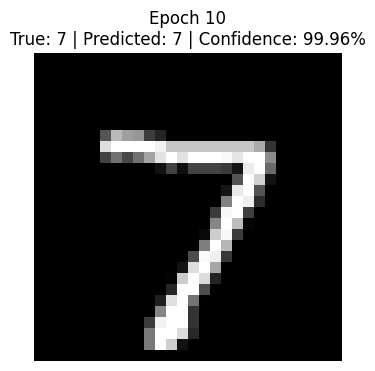


                         WEIGHT VITALS

W1 — INPUT → HIDDEN
--------------------------------------------------
Minimum   : -0.940464
Maximum   :  0.544695
Mean      : -0.001003
Std Dev   :  0.105932
L2 Norm   :  33.559044

W2 — HIDDEN → OUTPUT
--------------------------------------------------
Minimum   : -0.927614
Maximum   :  0.698393
Mean      : -0.030522
Std Dev   :  0.279521
L2 Norm   :  10.059876

GRADIENT VITALS
--------------------------------------------------
W1 Gradient L2 Norm : 0.234101
W2 Gradient L2 Norm : 0.200793

HIDDEN LAYER HEALTH
--------------------------------------------------
Dead ReLU Neurons : 1/128

                 FULL CONNECTION MATRICES

W1 CONNECTION MATRIX — 784 × 128
[[-6.1292879e-02 -7.9494260e-02 -1.6876958e-02 ... -1.6972877e-02
   5.1640950e-02 -5.4683838e-02]
 [-1.7797135e-02  3.8392536e-02 -7.1326166e-02 ... -6.0458489e-02
   1.5186146e-03  3.4088433e-02]
 [ 6.0737036e-02  3.9198503e-02  1.2963600e-02 ... -2.1864474e-03
   4.8626639e-02  5.8211

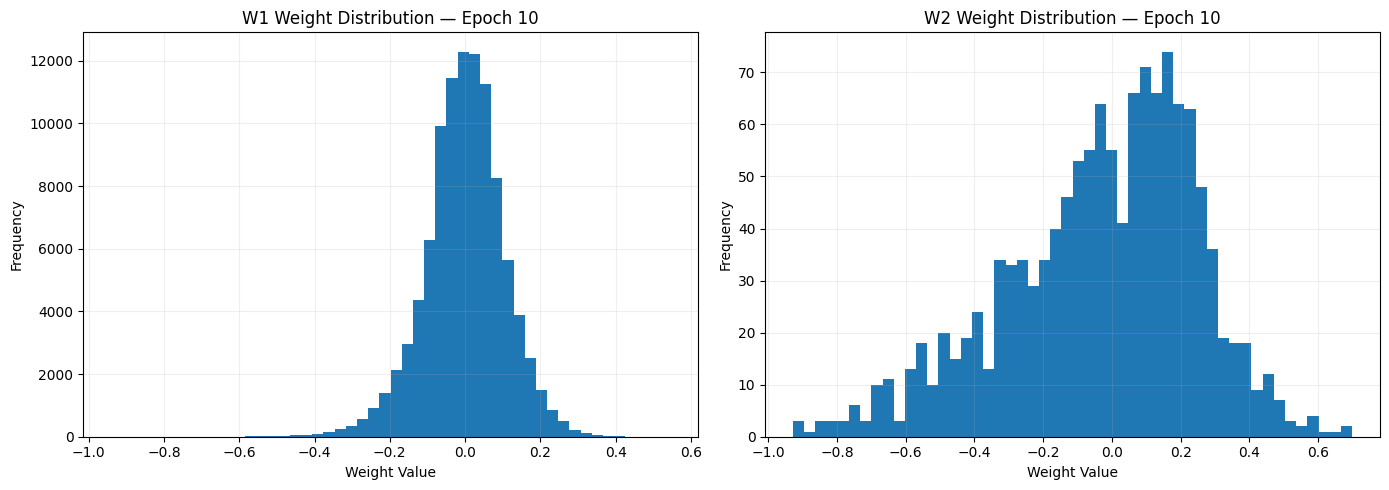


                  LEARNING EVOLUTION


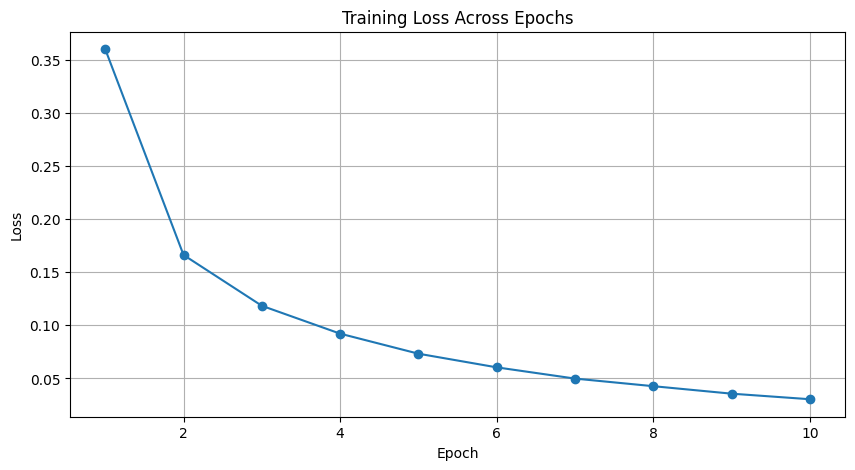

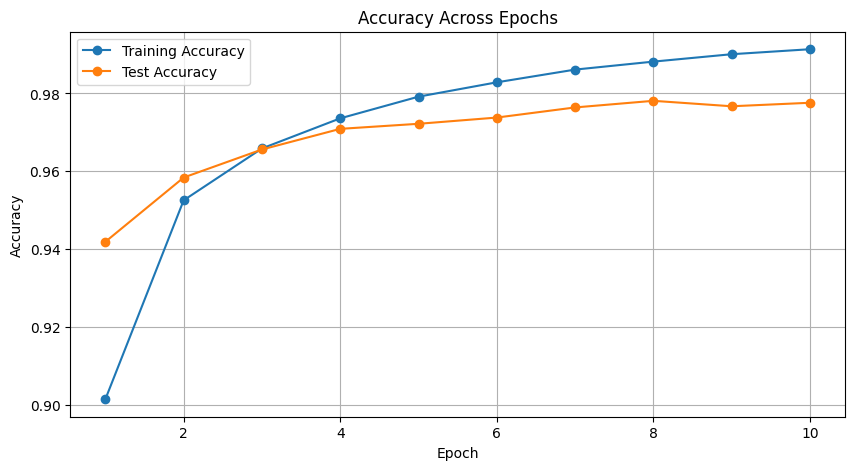

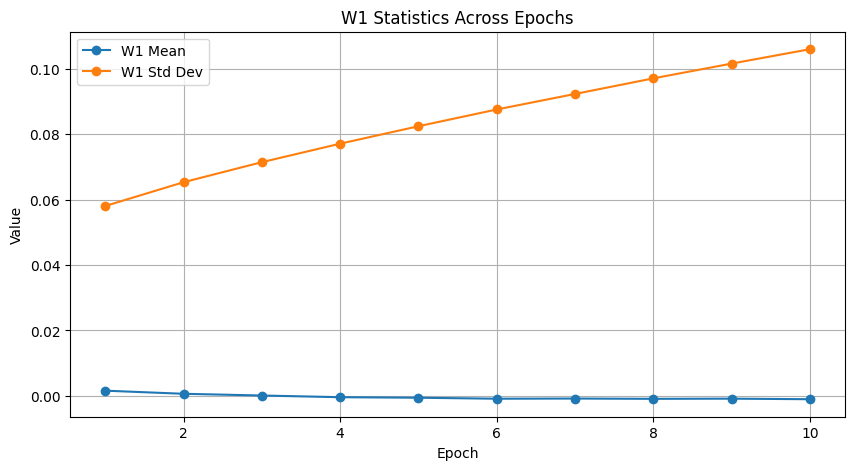

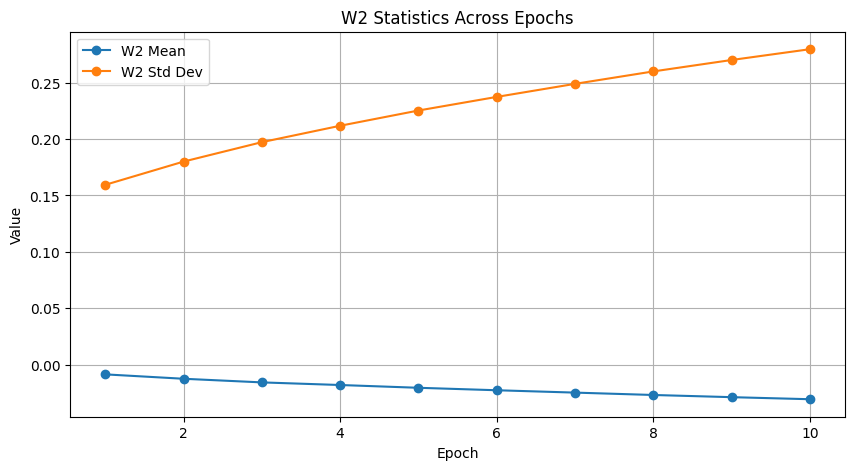

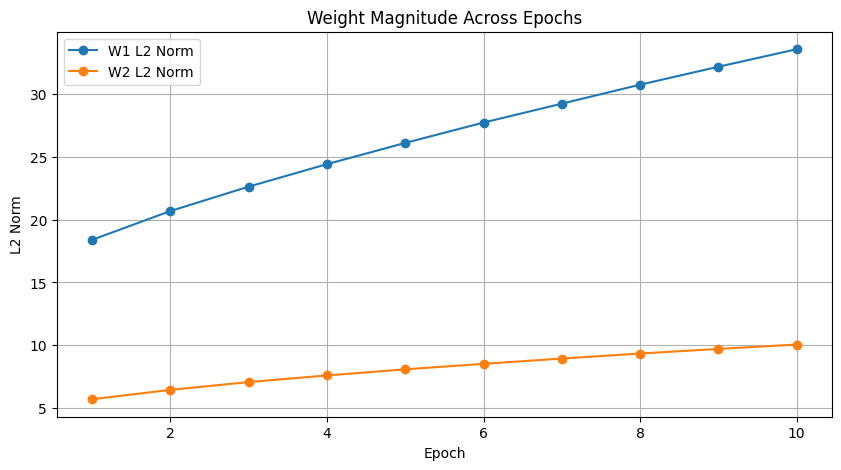

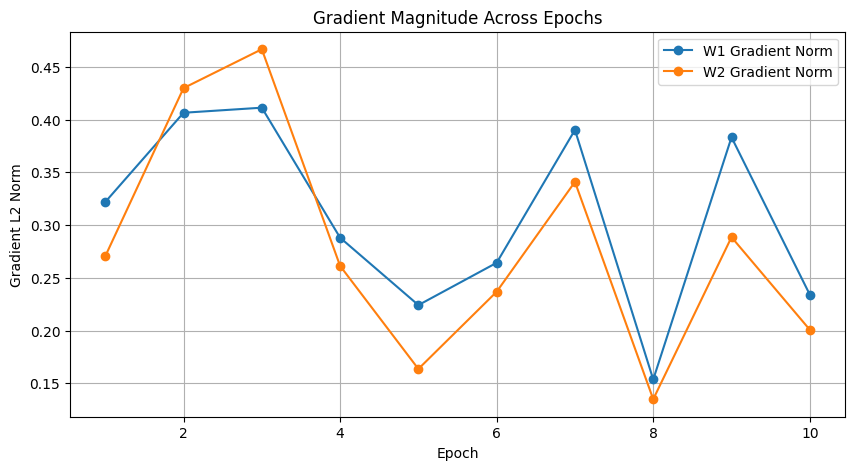

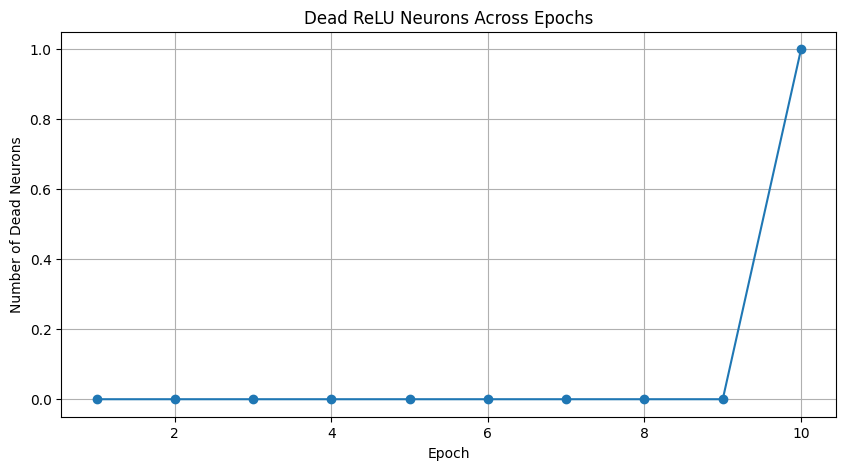



                       FINAL RESULTS

Final Test Accuracy : 97.7600%

FINAL W1 VITALS

W1 — INPUT → HIDDEN
--------------------------------------------------
Minimum   : -0.940464
Maximum   :  0.544695
Mean      : -0.001003
Std Dev   :  0.105932
L2 Norm   :  33.559044

FINAL W2 VITALS

W2 — HIDDEN → OUTPUT
--------------------------------------------------
Minimum   : -0.927614
Maximum   :  0.698393
Mean      : -0.030522
Std Dev   :  0.279521
L2 Norm   :  10.059876


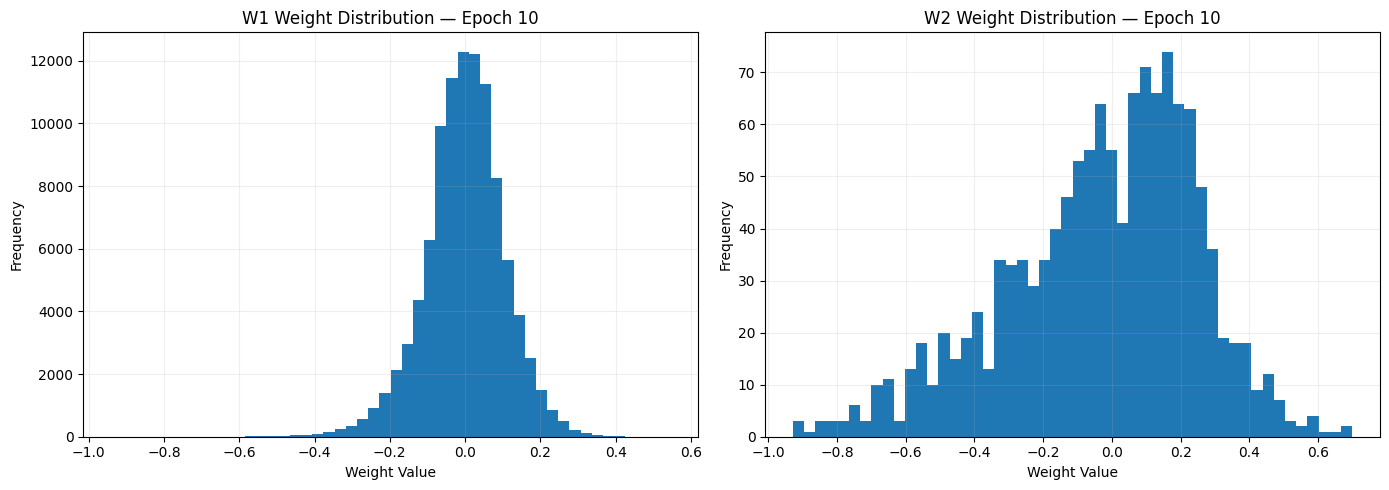

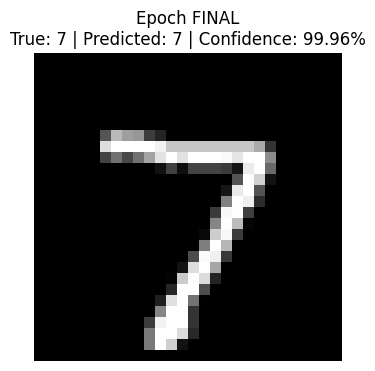



                    SURGERY SUMMARY
Architecture      : 784 → 128 → 10
Epochs            : 10
Batch Size        : 128
Optimizer         : Adam
Learning Rate     : 0.001
Final Test Accuracy: 97.7600%
Final W1 Norm     : 33.559044
Final W2 Norm     : 10.059876
Final W1 Mean     : -0.001003
Final W2 Mean     : -0.030522
Final W1 Std      : 0.105932
Final W2 Std      : 0.279521
Final Dead ReLU   : 1/128


In [5]:
# ============================================================
# ARTIFICIAL BRAIN SURGERY
# MNIST MLP WITH LIVE WEIGHT DIAGNOSTICS
#
# Architecture:
#       784 → 128 → 10
#
# Framework:
#       TensorFlow
#
# Diagnostics after every epoch:
#       - W1 and W2 statistics
#       - Weight histograms
#       - Loss
#       - Training/Test accuracy
#       - Weight evolution
#       - Gradient norms
#       - Dead ReLU neurons
#       - Fixed stimulus prediction
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


# ============================================================
# LOAD MNIST DATASET
# ============================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert labels to int64
y_train = y_train.astype("int64")
y_test = y_test.astype("int64")

print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing data :", X_test.shape)
print("Testing labels:", y_test.shape)

print("\nLabel datatype:", y_train.dtype)

# ============================================================
# 3. CREATE THE MLP
# ============================================================

model = tf.keras.Sequential([

    # Input
    tf.keras.Input(shape=(28, 28)),

    # 28 × 28 = 784
    tf.keras.layers.Flatten(),

    # Hidden layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])


# Display architecture
print("\nNETWORK ARCHITECTURE")
print("-" * 50)

model.summary()


# ============================================================
# 4. EXTRACT INITIAL WEIGHTS
# ============================================================

W1, b1 = model.layers[1].get_weights()
W2, b2 = model.layers[2].get_weights()

print("\nINITIAL CONNECTION INFORMATION")
print("-" * 50)

print("W1 Shape:", W1.shape)
print("W2 Shape:", W2.shape)

print("W1 Parameters:", W1.size)
print("W2 Parameters:", W2.size)

print("Total Weights:", W1.size + W2.size)


# ============================================================
# 5. DISPLAY INITIAL WEIGHTS
# ============================================================

print("\nINITIAL W1 CONNECTION MATRIX")
print("-" * 50)
print(W1)

print("\nINITIAL W2 CONNECTION MATRIX")
print("-" * 50)
print(W2)


# ============================================================
# 6. WEIGHT VITALS FUNCTION
# ============================================================

def weight_vitals(W, name):

    print(f"\n{name}")
    print("-" * 50)

    print(f"Minimum   : {np.min(W): .6f}")
    print(f"Maximum   : {np.max(W): .6f}")
    print(f"Mean      : {np.mean(W): .6f}")
    print(f"Std Dev   : {np.std(W): .6f}")
    print(f"L2 Norm   : {np.linalg.norm(W): .6f}")


# Display initial vitals

weight_vitals(
    W1,
    "W1 — INPUT → HIDDEN"
)

weight_vitals(
    W2,
    "W2 — HIDDEN → OUTPUT"
)


# ============================================================
# 7. LOSS FUNCTION AND OPTIMIZER
# ============================================================

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


# ============================================================
# 8. TRAINING CONFIGURATION
# ============================================================

epochs = 10

batch_size = 128

# How frequently to print the enormous W1/W2 matrices
matrix_print_frequency = 5


# ============================================================
# 9. CREATE TRAINING DATASET
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=10000,
        seed=42
    )
    .batch(batch_size)
)


# ============================================================
# 10. FIXED DIAGNOSTIC STIMULUS
# ============================================================
#
# We use the SAME image after every epoch.
#
# This allows us to observe:
#
#       Same input
#            ↓
#       Changing weights
#            ↓
#       Changing prediction
#            ↓
#       Changing confidence
#
# ============================================================

diagnostic_index = 0

diagnostic_image = X_test[
    diagnostic_index:diagnostic_index + 1
]

diagnostic_label = y_test[
    diagnostic_index
]


# ============================================================
# 11. HISTORY VARIABLES
# ============================================================

loss_history = []

training_accuracy_history = []

test_accuracy_history = []


# ------------------------------------------------------------
# W1 HISTORY
# ------------------------------------------------------------

W1_min_history = []
W1_max_history = []
W1_mean_history = []
W1_std_history = []
W1_norm_history = []


# ------------------------------------------------------------
# W2 HISTORY
# ------------------------------------------------------------

W2_min_history = []
W2_max_history = []
W2_mean_history = []
W2_std_history = []
W2_norm_history = []


# ------------------------------------------------------------
# GRADIENT HISTORY
# ------------------------------------------------------------

gradient_W1_norm_history = []
gradient_W2_norm_history = []


# ------------------------------------------------------------
# DEAD NEURON HISTORY
# ------------------------------------------------------------

dead_neuron_history = []


# ============================================================
# 12. FUNCTION TO PLOT WEIGHT HISTOGRAMS
# ============================================================

def plot_weight_histograms(W1, W2, epoch):

    plt.figure(figsize=(14, 5))

    # --------------------------------------------------------
    # W1 HISTOGRAM
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.hist(
        W1.flatten(),
        bins=50
    )

    plt.title(
        f"W1 Weight Distribution — Epoch {epoch}"
    )

    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    plt.grid(alpha=0.2)


    # --------------------------------------------------------
    # W2 HISTOGRAM
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.hist(
        W2.flatten(),
        bins=50
    )

    plt.title(
        f"W2 Weight Distribution — Epoch {epoch}"
    )

    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    plt.grid(alpha=0.2)

    plt.tight_layout()

    plt.show()


# ============================================================
# 13. FUNCTION TO SHOW FIXED STIMULUS
# ============================================================

def show_stimulus(
    image,
    true_label,
    prediction,
    confidence,
    epoch
):

    plt.figure(figsize=(4, 4))

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

    plt.title(
        f"Epoch {epoch}\n"
        f"True: {true_label} | "
        f"Predicted: {prediction} | "
        f"Confidence: {confidence:.2%}"
    )

    plt.show()


# ============================================================
# 14. FUNCTION TO PLOT LEARNING EVOLUTION
# ============================================================

def plot_learning_evolution():

    epoch_range = range(
        1,
        len(loss_history) + 1
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        loss_history,
        marker="o"
    )

    plt.title(
        "Training Loss Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        training_accuracy_history,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epoch_range,
        test_accuracy_history,
        marker="o",
        label="Test Accuracy"
    )

    plt.title(
        "Accuracy Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # W1 MEAN AND STD
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_mean_history,
        marker="o",
        label="W1 Mean"
    )

    plt.plot(
        epoch_range,
        W1_std_history,
        marker="o",
        label="W1 Std Dev"
    )

    plt.title(
        "W1 Statistics Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # W2 MEAN AND STD
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W2_mean_history,
        marker="o",
        label="W2 Mean"
    )

    plt.plot(
        epoch_range,
        W2_std_history,
        marker="o",
        label="W2 Std Dev"
    )

    plt.title(
        "W2 Statistics Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # WEIGHT NORMS
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_norm_history,
        marker="o",
        label="W1 L2 Norm"
    )

    plt.plot(
        epoch_range,
        W2_norm_history,
        marker="o",
        label="W2 L2 Norm"
    )

    plt.title(
        "Weight Magnitude Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("L2 Norm")

    plt.legend()

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # GRADIENT NORMS
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        gradient_W1_norm_history,
        marker="o",
        label="W1 Gradient Norm"
    )

    plt.plot(
        epoch_range,
        gradient_W2_norm_history,
        marker="o",
        label="W2 Gradient Norm"
    )

    plt.title(
        "Gradient Magnitude Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Gradient L2 Norm")

    plt.legend()

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # DEAD RELU NEURONS
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        dead_neuron_history,
        marker="o"
    )

    plt.title(
        "Dead ReLU Neurons Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Number of Dead Neurons")

    plt.grid(True)

    plt.show()


# ============================================================
# 15. MAIN TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    # --------------------------------------------------------
    # RESET EPOCH STATISTICS
    # --------------------------------------------------------

    epoch_loss = 0.0

    correct = 0

    total = 0

    last_gradients = None


    # ========================================================
    # TRAIN FOR ONE COMPLETE EPOCH
    # ========================================================

    for images, labels in train_dataset:

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        with tf.GradientTape() as tape:

            predictions = model(
                images,
                training=True
            )

            loss = loss_fn(
                labels,
                predictions
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )

        last_gradients = gradients


        # ----------------------------------------------------
        # UPDATE PARAMETERS
        # ----------------------------------------------------

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )


        # ----------------------------------------------------
        # TRAINING LOSS
        # ----------------------------------------------------

        current_batch_size = images.shape[0]

        epoch_loss += (
            loss.numpy() *
            current_batch_size
        )


        # ----------------------------------------------------
        # TRAINING ACCURACY
        # ----------------------------------------------------

        predicted_labels = tf.argmax(
            predictions,
            axis=1
        )

        correct += tf.reduce_sum(
            tf.cast(
                predicted_labels == labels,
                tf.int32
            )
        ).numpy()

        total += current_batch_size


    # ========================================================
    # CALCULATE EPOCH METRICS
    # ========================================================

    epoch_loss /= total

    epoch_accuracy = (
        correct / total
    )


    # ========================================================
    # TEST ACCURACY
    # ========================================================

    test_predictions = model(
        X_test,
        training=False
    )

    test_predicted_labels = tf.argmax(
        test_predictions,
        axis=1
    )

    test_accuracy = np.mean(
        test_predicted_labels.numpy()
        == y_test
    )


    # ========================================================
    # SAVE BASIC HISTORY
    # ========================================================

    loss_history.append(
        epoch_loss
    )

    training_accuracy_history.append(
        epoch_accuracy
    )

    test_accuracy_history.append(
        test_accuracy
    )


    # ========================================================
    # EXTRACT UPDATED WEIGHTS
    # ========================================================

    W1, b1 = model.layers[1].get_weights()

    W2, b2 = model.layers[2].get_weights()


    # ========================================================
    # W1 DIAGNOSTICS
    # ========================================================

    W1_min_history.append(
        np.min(W1)
    )

    W1_max_history.append(
        np.max(W1)
    )

    W1_mean_history.append(
        np.mean(W1)
    )

    W1_std_history.append(
        np.std(W1)
    )

    W1_norm_history.append(
        np.linalg.norm(W1)
    )


    # ========================================================
    # W2 DIAGNOSTICS
    # ========================================================

    W2_min_history.append(
        np.min(W2)
    )

    W2_max_history.append(
        np.max(W2)
    )

    W2_mean_history.append(
        np.mean(W2)
    )

    W2_std_history.append(
        np.std(W2)
    )

    W2_norm_history.append(
        np.linalg.norm(W2)
    )


    # ========================================================
    # GRADIENT DIAGNOSTICS
    # ========================================================

    # TensorFlow trainable variables:
    #
    # [W1, b1, W2, b2]
    #
    # Therefore:
    #
    # gradients[0] -> W1
    # gradients[1] -> b1
    # gradients[2] -> W2
    # gradients[3] -> b2

    gradient_W1_norm = np.linalg.norm(
        last_gradients[0].numpy()
    )

    gradient_W2_norm = np.linalg.norm(
        last_gradients[2].numpy()
    )

    gradient_W1_norm_history.append(
        gradient_W1_norm
    )

    gradient_W2_norm_history.append(
        gradient_W2_norm
    )


    # ========================================================
    # DEAD RELU NEURON ANALYSIS
    # ========================================================
    #
    # Run the training data through the hidden layer.
    #
    # A neuron is considered "dead" here if its activation
    # is zero for the entire diagnostic batch.
    #
    # We use 1000 samples for efficiency.
    # ========================================================

    diagnostic_batch = tf.convert_to_tensor(
        X_train[:1000]
    )

    hidden_output = model.layers[1](
        model.layers[0](
            diagnostic_batch
        )
    )

    dead_neurons = np.sum(
        np.all(
            hidden_output.numpy() <= 0,
            axis=0
        )
    )

    dead_neuron_history.append(
        dead_neurons
    )


    # ========================================================
    # FIXED STIMULUS PREDICTION
    # ========================================================

    diagnostic_prediction = model(
        diagnostic_image,
        training=False
    )

    predicted_digit = np.argmax(
        diagnostic_prediction.numpy()
    )

    confidence = np.max(
        diagnostic_prediction.numpy()
    )


    # ========================================================
    # CLEAR PREVIOUS EPOCH DISPLAY
    # ========================================================

    clear_output(wait=True)


    # ========================================================
    # ARTIFICIAL BRAIN SURGERY REPORT
    # ========================================================

    print("=" * 75)

    print(
        "                    ARTIFICIAL BRAIN SURGERY"
    )

    print("=" * 75)

    print(
        f"\nEPOCH {epoch + 1}/{epochs}"
    )

    print("-" * 75)

    print(
        f"Training Loss     : {epoch_loss:.6f}"
    )

    print(
        f"Training Accuracy : {epoch_accuracy:.4%}"
    )

    print(
        f"Test Accuracy     : {test_accuracy:.4%}"
    )


    # ========================================================
    # NETWORK INFORMATION
    # ========================================================

    print("\nNETWORK ARCHITECTURE")

    print("-" * 50)

    print(
        "Input Layer       : 784 neurons"
    )

    print(
        "Hidden Layer      : 128 neurons — ReLU"
    )

    print(
        "Output Layer      : 10 neurons — Softmax"
    )

    print(
        "\nW1 : 784 × 128 =",
        W1.size,
        "weights"
    )

    print(
        "W2 : 128 × 10  =",
        W2.size,
        "weights"
    )

    print(
        "Total Weights    :",
        W1.size + W2.size
    )


    # ========================================================
    # FIXED STIMULUS
    # ========================================================

    print("\nCURRENT STIMULUS")

    print("-" * 50)

    print(
        f"True Digit       : {diagnostic_label}"
    )

    print(
        f"Prediction       : {predicted_digit}"
    )

    print(
        f"Confidence       : {confidence:.4%}"
    )

    show_stimulus(
        diagnostic_image[0],
        diagnostic_label,
        predicted_digit,
        confidence,
        epoch + 1
    )


    # ========================================================
    # WEIGHT VITALS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                         WEIGHT VITALS"
    )

    print("=" * 75)

    weight_vitals(
        W1,
        "W1 — INPUT → HIDDEN"
    )

    weight_vitals(
        W2,
        "W2 — HIDDEN → OUTPUT"
    )


    # ========================================================
    # GRADIENT VITALS
    # ========================================================

    print("\nGRADIENT VITALS")

    print("-" * 50)

    print(
        f"W1 Gradient L2 Norm : "
        f"{gradient_W1_norm:.6f}"
    )

    print(
        f"W2 Gradient L2 Norm : "
        f"{gradient_W2_norm:.6f}"
    )


    # ========================================================
    # DEAD NEURON DIAGNOSTIC
    # ========================================================

    print("\nHIDDEN LAYER HEALTH")

    print("-" * 50)

    print(
        f"Dead ReLU Neurons : "
        f"{dead_neurons}/128"
    )


    # ========================================================
    # FULL MATRICES
    # ========================================================
    #
    # W1 contains 100,352 values, so printing it every epoch
    # creates enormous Colab output.
    #
    # Therefore, print complete matrices:
    #
    #   Epoch 1
    #   Every 5th epoch
    #
    # ========================================================

    if (
        epoch == 0
        or (epoch + 1) % matrix_print_frequency == 0
    ):

        print("\n" + "=" * 75)

        print(
            "                 FULL CONNECTION MATRICES"
        )

        print("=" * 75)

        print(
            "\nW1 CONNECTION MATRIX — 784 × 128"
        )

        print(W1)

        print(
            "\nW2 CONNECTION MATRIX — 128 × 10"
        )

        print(W2)

    else:

        print("\nFULL MATRICES")

        print("-" * 50)

        print(
            "W1 and W2 matrices are hidden for this epoch."
        )

        print(
            f"Full matrices will be displayed "
            f"every {matrix_print_frequency} epochs."
        )


    # ========================================================
    # HISTOGRAMS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                  CURRENT WEIGHT DISTRIBUTIONS"
    )

    print("=" * 75)

    plot_weight_histograms(
        W1,
        W2,
        epoch + 1
    )


    # ========================================================
    # EVOLUTION PLOTS
    # ========================================================
    #
    # These plots update after every epoch.
    #
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                  LEARNING EVOLUTION"
    )

    print("=" * 75)

    plot_learning_evolution()


# ============================================================
# 16. FINAL EVALUATION
# ============================================================

print("\n")
print("=" * 75)

print(
    "                       FINAL RESULTS"
)

print("=" * 75)


# Final predictions

final_predictions = model(
    X_test,
    training=False
)

final_predicted_labels = tf.argmax(
    final_predictions,
    axis=1
).numpy()


# Final accuracy

final_accuracy = np.mean(
    final_predicted_labels == y_test
)


print(
    f"\nFinal Test Accuracy : "
    f"{final_accuracy:.4%}"
)


# ============================================================
# 17. FINAL WEIGHTS
# ============================================================

W1, b1 = model.layers[1].get_weights()

W2, b2 = model.layers[2].get_weights()


print("\nFINAL W1 VITALS")

weight_vitals(
    W1,
    "W1 — INPUT → HIDDEN"
)


print("\nFINAL W2 VITALS")

weight_vitals(
    W2,
    "W2 — HIDDEN → OUTPUT"
)


# ============================================================
# 18. FINAL WEIGHT HISTOGRAMS
# ============================================================

plot_weight_histograms(
    W1,
    W2,
    epochs
)


# ============================================================
# 19. FINAL DIAGNOSTIC IMAGE
# ============================================================

final_prediction = model(
    diagnostic_image,
    training=False
)

final_digit = np.argmax(
    final_prediction.numpy()
)

final_confidence = np.max(
    final_prediction.numpy()
)


show_stimulus(
    diagnostic_image[0],
    diagnostic_label,
    final_digit,
    final_confidence,
    "FINAL"
)


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 75)

print(
    "                    SURGERY SUMMARY"
)

print("=" * 75)

print(
    f"Architecture      : 784 → 128 → 10"
)

print(
    f"Epochs            : {epochs}"
)

print(
    f"Batch Size        : {batch_size}"
)

print(
    f"Optimizer         : Adam"
)

print(
    f"Learning Rate     : 0.001"
)

print(
    f"Final Test Accuracy: {final_accuracy:.4%}"
)

print(
    f"Final W1 Norm     : {np.linalg.norm(W1):.6f}"
)

print(
    f"Final W2 Norm     : {np.linalg.norm(W2):.6f}"
)

print(
    f"Final W1 Mean     : {np.mean(W1):.6f}"
)

print(
    f"Final W2 Mean     : {np.mean(W2):.6f}"
)

print(
    f"Final W1 Std      : {np.std(W1):.6f}"
)

print(
    f"Final W2 Std      : {np.std(W2):.6f}"
)

print(
    f"Final Dead ReLU   : {dead_neuron_history[-1]}/128"
)

print("=" * 75)